In [34]:
import pandas as pd


In [35]:
df = pd.read_csv("/content/drive/MyDrive/Diabetes Missing Data (1).csv") # Loading data

In [36]:

df.head() # This will give first 5 rows in the dataframe

,Unnamed: 0,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,Diabetes
1,1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,No Diabetes
2,2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,Diabetes
3,3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,No Diabetes
4,4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Diabetes


In [37]:
df = df.drop(columns=['Unnamed: 0']) # Removing unnecessery column

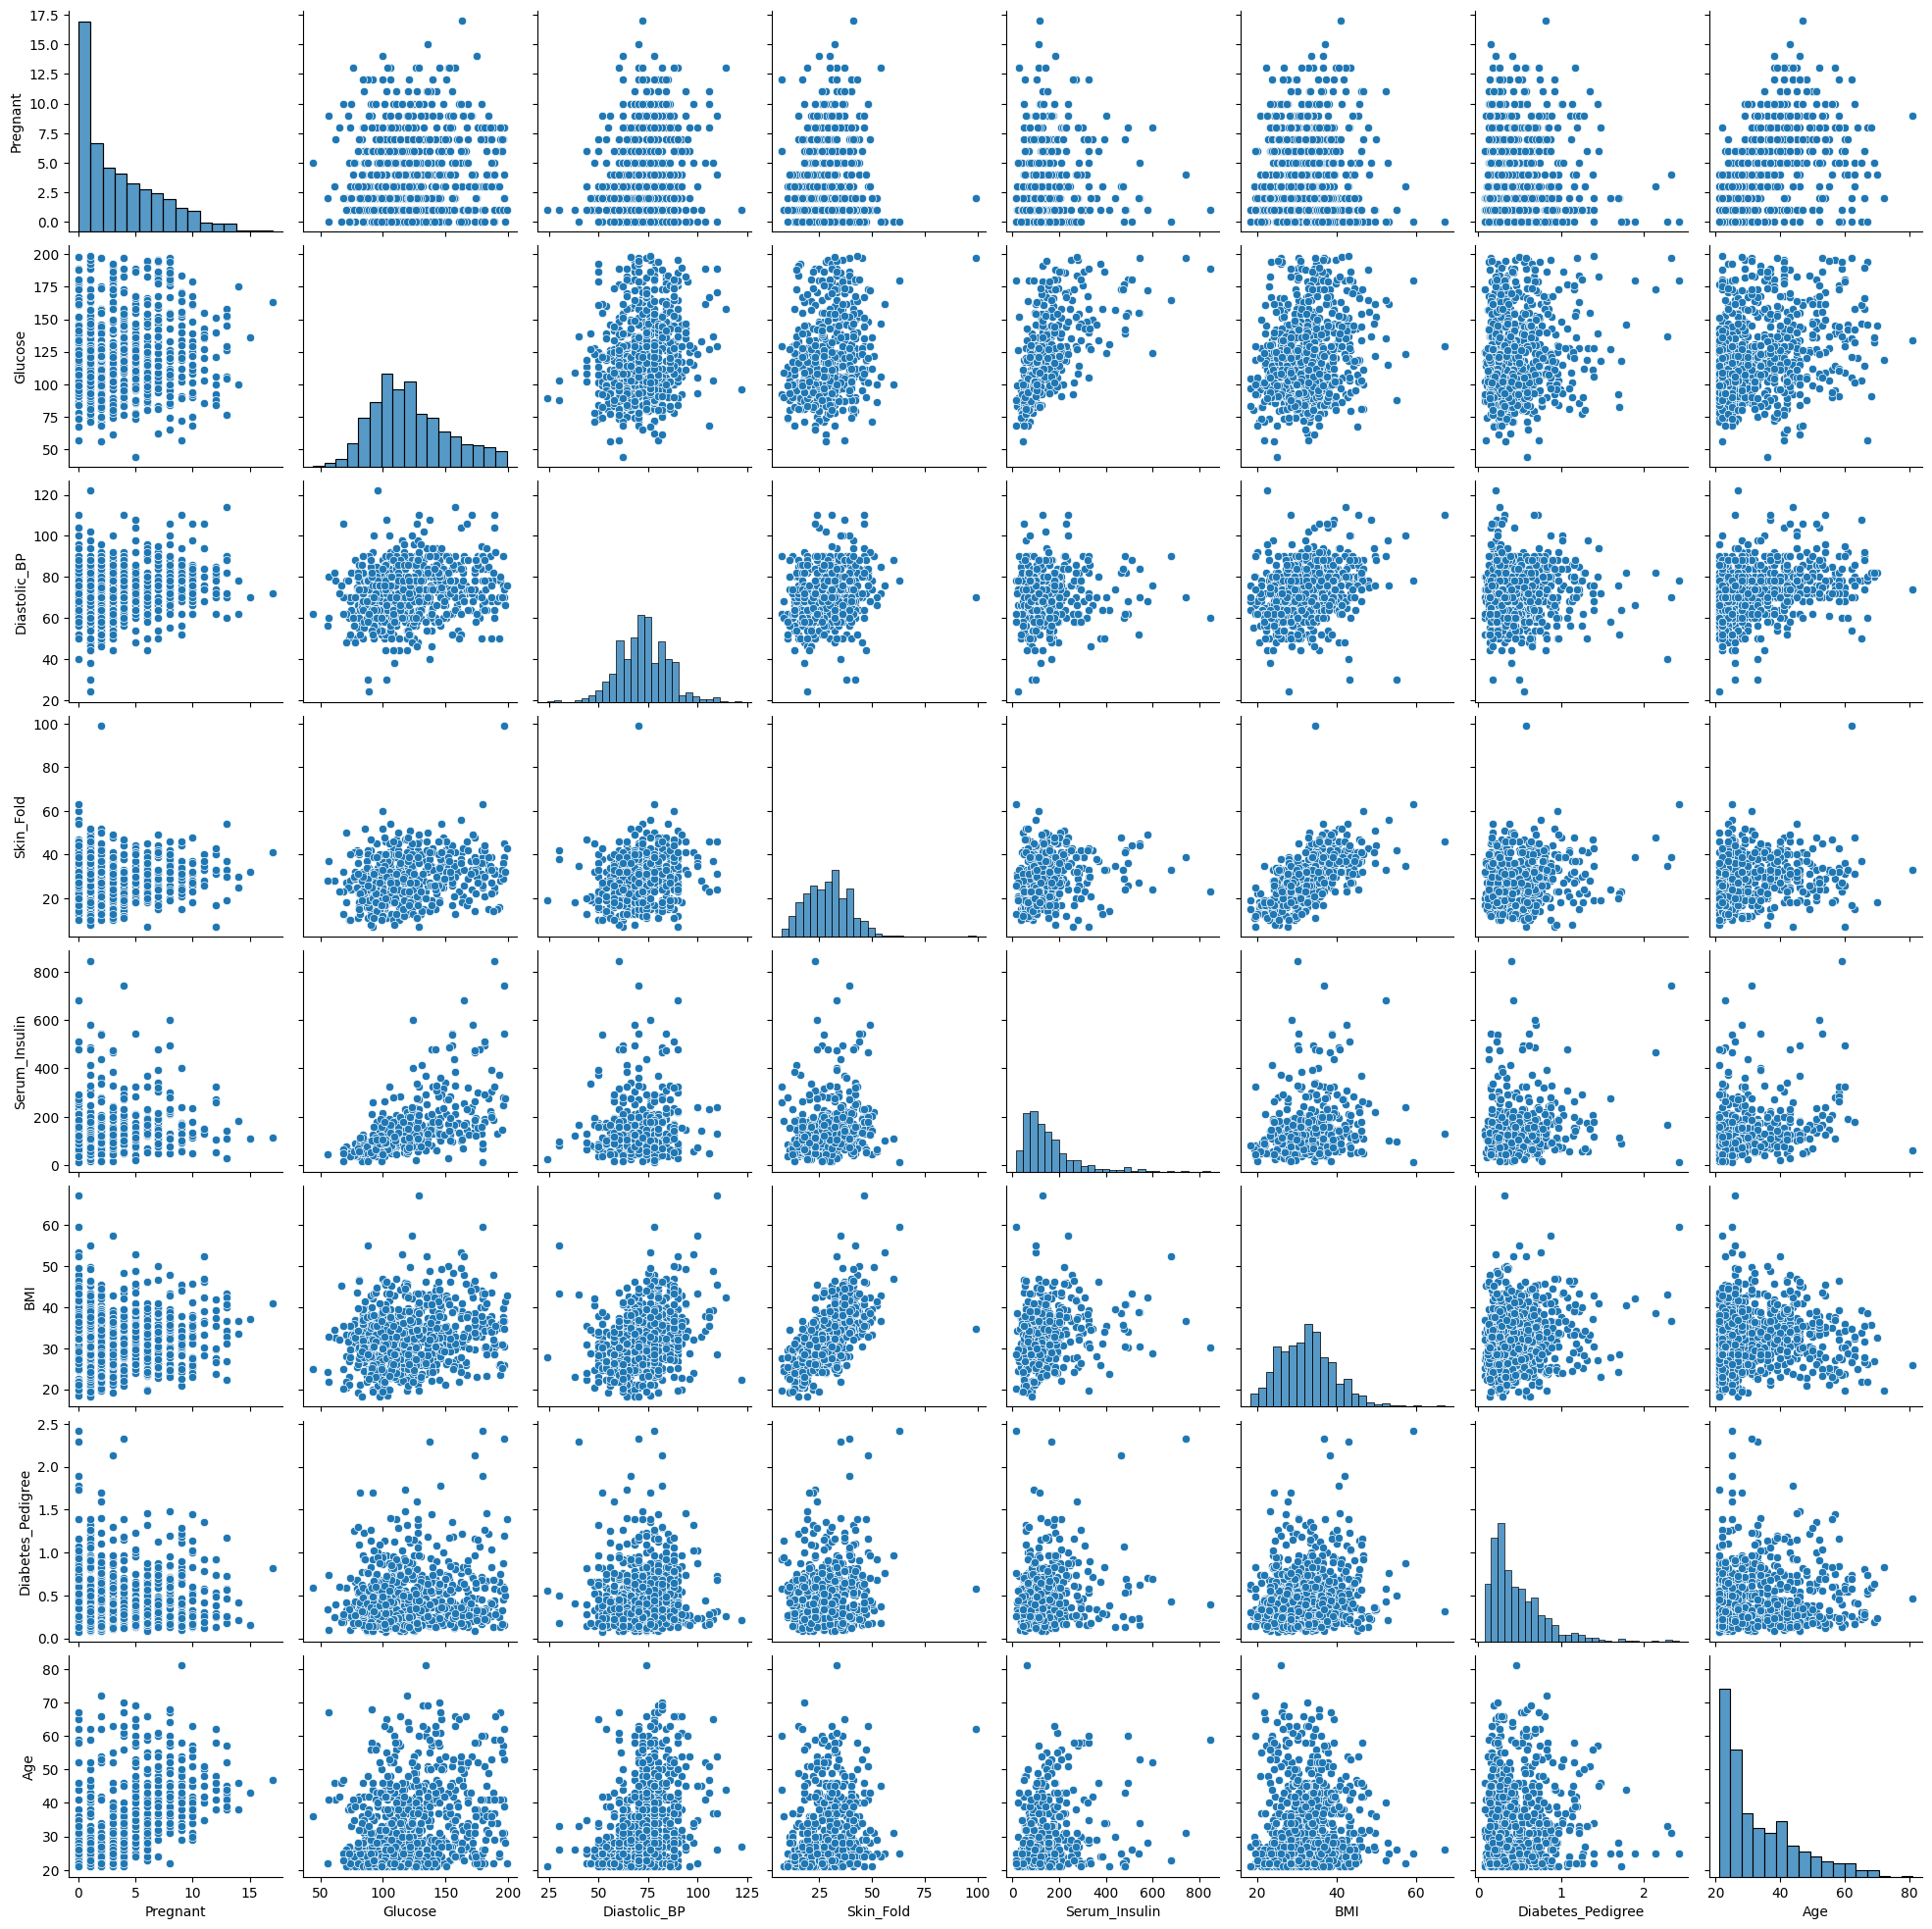

In [38]:
import seaborn as sns
sns.pairplot(df) # This will give matrix of scatter plots that tells relationship of 2 attributes in the dataset


<Axes: >

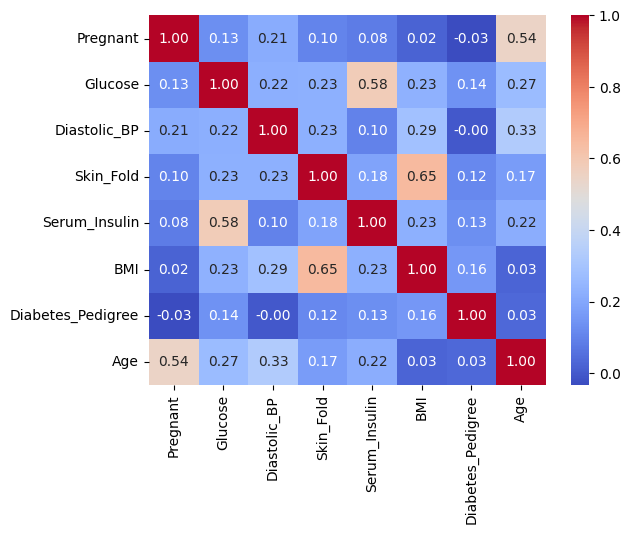

In [39]:
corr_data = df.drop(columns=['Class'])
corr_data = corr_data.corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')

In [40]:
df.isna() # Returns True is the value is null or Nan and false otherwise
df.isna().sum() # This returns sum of null values in every feature
df.isna().sum().sum() # This function returns total null or NaN values present in the dataset

np.int64(652)

In [41]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean()) # Filling NaN values present in feature glucose with its mean value
df.isna().sum()

,0
Pregnant,0
Glucose,0
Diastolic_BP,35
Skin_Fold,227
Serum_Insulin,374
BMI,11
Diabetes_Pedigree,0
Age,0
Class,0


In [42]:
# Similar to glucose by replacing features
df['Diastolic_BP'] = df['Diastolic_BP'].fillna(df['Diastolic_BP'].mean())
df['Skin_Fold'] = df['Skin_Fold'].fillna(df['Skin_Fold'].median())  # Filling with median
df['Serum_Insulin'] = df['Serum_Insulin'].fillna(df['Serum_Insulin'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df.isna().sum()


,0
Pregnant,0
Glucose,0
Diastolic_BP,0
Skin_Fold,0
Serum_Insulin,0
BMI,0
Diabetes_Pedigree,0
Age,0
Class,0


In [43]:
from sklearn.preprocessing import LabelEncoder # Pre-defined function for encoding labels
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
df

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.0,35.0,155.548223,33.6,0.627,50,0
1,1,85.0,66.0,29.0,155.548223,26.6,0.351,31,1
2,8,183.0,64.0,29.0,155.548223,23.3,0.672,32,0
3,1,89.0,66.0,23.0,94.000000,28.1,0.167,21,1
4,0,137.0,40.0,35.0,168.000000,43.1,2.288,33,0
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.000000,32.9,0.171,63,1
764,2,122.0,70.0,27.0,155.548223,36.8,0.340,27,1
765,5,121.0,72.0,23.0,112.000000,26.2,0.245,30,1
766,1,126.0,60.0,29.0,155.548223,30.1,0.349,47,0


In [44]:
x = df.drop(columns=['Class'])
y = df['Class']


In [45]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, shuffle=True)  # 0.2 means dividing 20% data as test data


In [46]:
print("x_train shape : ",x_train.shape)
print("x_test shape : ",x_test.shape)
print("y_train shape : ",y_train.shape)
print("y_test shape : ",y_test.shape)


x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)


In [47]:
# Kfold cross validation
from sklearn.model_selection import KFold
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

for train_index, test_index in kf.split(x):

  x_train, x_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  print("x_train shape : ", x_train.shape)
  print("x_test shape : ", x_test.shape)
  print("y_train shape : ", y_train.shape)
  print("y_test shape : ", y_test.shape)
  print()


x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)

x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)

x_train shape :  (614, 8)
x_test shape :  (154, 8)
y_train shape :  (614,)
y_test shape :  (154,)

x_train shape :  (615, 8)
x_test shape :  (153, 8)
y_train shape :  (615,)
y_test shape :  (153,)

x_train shape :  (615, 8)
x_test shape :  (153, 8)
y_train shape :  (615,)
y_test shape :  (153,)



In [48]:
# Min-Max scaling
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
mms_data = mms.fit_transform(df)
mms_data = pd.DataFrame(mms_data, columns=df.columns)
mms_data.head()

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0.352941,0.670968,0.489796,0.304348,0.170130,0.314928,0.234415,0.483333,0.0
1,0.058824,0.264516,0.428571,0.239130,0.170130,0.171779,0.116567,0.166667,1.0
2,0.470588,0.896774,0.408163,0.239130,0.170130,0.104294,0.253629,0.183333,0.0
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,1.0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,0.0


In [49]:
# Normalization
from sklearn.preprocessing import Normalizer
norm = Normalizer()
norm_data = norm.fit_transform(df)
norm_data = pd.DataFrame(norm_data, columns=df.columns)
norm_data.head()

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0.025315,0.624447,0.303785,0.147673,0.656295,0.141766,0.002645,0.210962,0.000000
1,0.005111,0.434398,0.337297,0.148206,0.794940,0.135941,0.001794,0.158428,0.005111
2,0.031561,0.721948,0.252484,0.114407,0.613649,0.091920,0.002651,0.126242,0.000000
3,0.006612,0.588455,0.436382,0.152073,0.621514,0.185793,0.001104,0.138849,0.006612
4,0.000000,0.596386,0.174127,0.152361,0.731335,0.187622,0.009960,0.143655,0.000000


In [50]:
# Standardization
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss_data = ss.fit_transform(df)
ss_data = pd.DataFrame(ss_data, columns=df.columns)
ss_data.head()


,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,0.639947,0.865108,-0.033518,0.670643,-3.345079e-16,0.166292,0.468492,1.425995,-1.365896
1,-0.844885,-1.206162,-0.529859,-0.012301,-3.345079e-16,-0.852531,-0.365061,-0.190672,0.732120
2,1.233880,2.015813,-0.695306,-0.012301,-3.345079e-16,-1.332833,0.604397,-0.105584,-1.365896
3,-0.844885,-1.074652,-0.529859,-0.695245,-7.243887e-01,-0.634212,-0.920763,-1.041549,0.732120
4,-1.141852,0.503458,-2.680669,0.670643,1.465506e-01,1.548980,5.484909,-0.020496,-1.365896
